In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# ১. সেভ করা Keras মডেল লোড
model = tf.keras.models.load_model('../models/ai_real_detector.keras')

# ২. টেস্ট ডাটা লোড
test_dir = r"C:\Users\Promi\Downloads\archive\test" # আপনার টেস্ট ফোল্ডারের পাথ

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(32, 32),
    batch_size=64,
    shuffle=False # Evaluation এর জন্য shuffle=False রাখা জরুরি
)

class_names = test_ds.class_names
print("Classes:", class_names)

C:\Users\Promi\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 20000 files belonging to 2 classes.
Classes: ['FAKE', 'REAL']


In [3]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9275 - loss: 0.1970

Test Accuracy: 92.75%
Test Loss: 0.1970


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        FAKE       0.91      0.95      0.93     10000
        REAL       0.94      0.91      0.93     10000

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



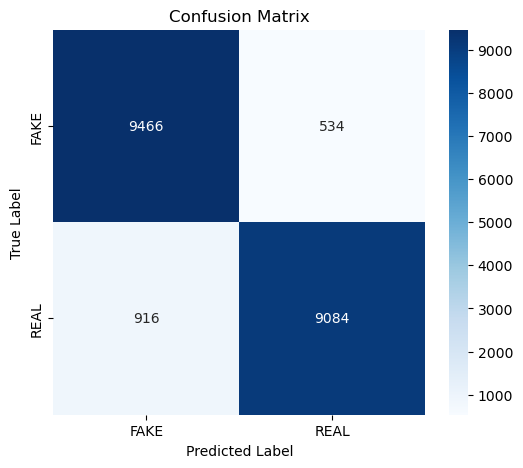

In [4]:
# টেস্ট ডাটার প্রেডিকশন বের করা
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
predictions = model.predict(test_ds)
y_pred = (predictions > 0.5).astype("int32").flatten()

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Visual
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [5]:
import sys
import os
print(f'"{sys.executable}" -m streamlit run "{os.path.abspath("../app.py")}"')

"C:\ProgramData\anaconda3\python.exe" -m streamlit run "C:\Users\Promi\Desktop\AI & Real Images_Detection\app.py"


In [1]:
import sys
print(sys.executable)


C:\ProgramData\anaconda3\python.exe
